# HW 3 Computer Vision
This assignment is designed to assess your understanding of key concepts in computer vision, neural networks and object recognition.

**Submission Guidelines:**

- Notebook Submission: Complete your solutions within this notebook file.
- PDF Submission: Export your completed notebook as a PDF and submit it alongside the notebook.

**Important Notes:**

- Submissions without a PDF le will incur a 10% penalty on the total grade.
- Ensure that your code runs without errors and that all visual outputs are included in the PDF.
- Write clear and concise explanations for your code and make sure to add comments in each part of your code.
- Code with no comments will lose 10% of the question mark.
Properly format your code and comments to enhance readability.


## MCQs Part 1 (10 marks)
1.What is the primary purpose of convolution in image processing?

- [ ] Increasing image resolution
- [x] Extracting features by weighted sum of neighbouring pixels
- [ ] Compressing image size
- [ ] Colour correction

2. What is the main advantage of using machine learning for feature extraction?

- [ ] It is faster than manual design
- [ ] It always produces more accurate results
- [x] The algorithm autonomously designs the filter through learned patterns
- [ ] It requires less data

3. What is the goal of training an ANN?
- [ ] maximize the error between predicted and actual outputs
- [x] minimize the error between predicted output h(x) and ground truth value y
- [ ] increase the complexity of the model
- [ ] reduce the number of training examples

4. What is the role of the bias term in an ANN?
- [ ] scale the input values
- [ ] introduce non-linearity
- [x] provide an offset to the weighted sum of inputs
- [ ] normalize the output

5. What is the purpose of the activation function in a neural network?
- [ ] normalize the input data
- [ ] reduce the dimensionality of the data
- [x] introduce non-linearity into the network
- [ ] speed up the training process

6. What is the purpose of the Softmax function in classification?
- [ ] predict continuous values
- [x] estimate the probability for each class
- [ ] reduce the dimensionality of the input
- [ ] speed up the training process

7. What is the purpose of the forward pass in the generalized backpropagation algorithm?

- [ ] Compute gradients
- [ ] Update weights
- [x] Compute the output of the network
- [ ] Minimize loss function

8. What is the purpose of the backward pass in the generalized backpropagation algorithm?
- [ ] Compute the output of the network
- [ ] Update weights
- [x] Compute gradients
- [ ] Minimize loss function

9. What is the last step in the generalized backpropagation algorithm?
- [ ] Compute gradients
- [x] Update weights
- [ ] Compute the output of the network
- [ ] Minimize loss function

10. What is a common loss function used in Softmax classification?
- [ ] Squared Loss
- [ ] Mean Absolute Error
- [x] Cross Entropy Loss
- [ ] Hinge Loss

## Theoritical questions Part 2 (6 marks)

1. Explain how convolution can be perceived as a feature matching process, and how this relates to the shift from manual feature engineering to machine learning using Artificial Neural Networks (ANNs). (3 marks)

**Ans:**
Convolution can be seen as a feature matching process because filters in a convolutional layer act like detectors that slide across the input data, looking for specific patterns such as edges or textures. When a filter matches a pattern in a region of the input, it produces a high activation value, indicating the presence of that feature at that location. This idea connects directly to the way Artificial Neural Networks (ANNs), particularly Convolutional Neural Networks (CNNs), learn to identify important features in data. Instead of being given explicit instructions on what to look for, the network automatically learns and refines these filters during training. This shift allows the model to extract relevant features from raw input data, leading to more accurate and efficient learning across various tasks.

2. Describe the general backpropagation algorithm, including what the forward and backward passes do, and explain why activation functions are important

**Ans:**
The backpropagation algorithm is a key process in training artificial neural networks, and it involves two main stages: the forward pass and the backward pass. In the forward pass, input data is passed through the network layer by layer. Each neuron takes weighted inputs, adds a bias, and passes the result through an activation function to produce an output. This continues until the final output is generated. At this point, the network compares the predicted output to the actual target using a loss function, which calculates the error.

In the backward pass, the algorithm calculates how much each weight in the network contributed to the error by applying the chain rule of calculus. These gradients are then used to update the weights in a way that minimizes the loss, typically using gradient descent. This backward adjustment is what allows the network to learn and improve its predictions over time.

Activation functions are an essential part of this process because they introduce non-linearity into the network. Without them, the model would only be able to learn linear relationships, no matter how many layers it has. Activation functions like ReLU, and Sigmoid allow the network to capture more complex patterns and behaviors in the data. They also help control the output values and influence how the gradients behave during backpropagation, which directly affects how well the network learns.

## Coding part 3 (30 marks)



### Question 1: Build a Simple CNN from Scratch

Construct a simple CNN model from scratch to classify a subset of CIFAR-10 images. Your solution must include:

- Data Preprocessing (2 marks): Normalize and (optionally) augment the images.

- CNN Architecture, Activation Functions, & Weight Initialization (3 marks): Build a CNN with at least two convolutional layers using ReLU; initialize weights using a suitable method (e.g., Kaiming).

- Batch Normalization & Regularization (2 marks): Include batch normalization layers and dropout for regularization.

- Optimization & Learning Rate Scheduling (2 marks): Use an optimizer (e.g., Adam) and implement a learning rate scheduler.

- Three-way Split & Error Metrics (1 mark): Split your data into train/validation/test sets and compute accuracy as the error metric.

In [1]:
# Import necessary libraries
import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import numpy as np

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(f"Using device: {device}")

Using device: mps


In [2]:
# Data Preprocessing
torch.manual_seed(0)
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Data augmentation (optional)
    transforms.RandomCrop(32, padding=4),  # Data augmentation (optional)
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean = (0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))  # Normalize
])

# Load CIFAR-10 dataset
dataset = datasets.CIFAR10(root='./.torch/data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./.torch/data', train=False, download=True, transform=transform)

# Split dataset into train, validation, and test sets
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

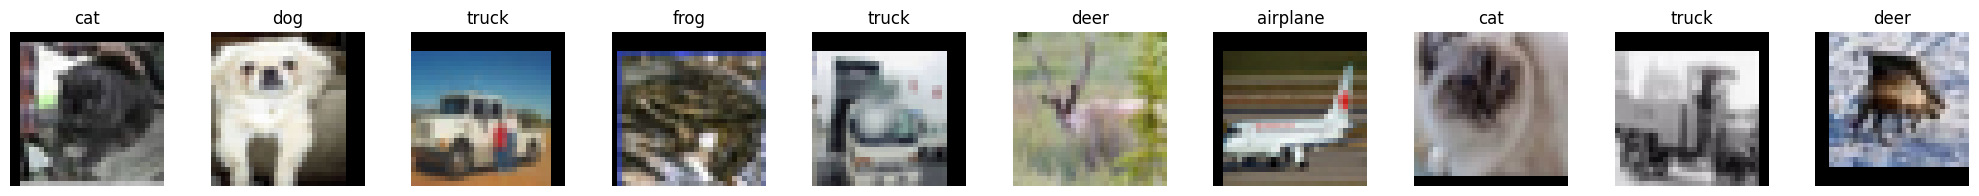

In [9]:
transform_back = transforms.Compose([transforms.Normalize((-2.11,-2.03,-1.8),(4.37,4.46,4.44)), 
                            transforms.ToPILImage()])

images, labels =  next(iter(train_loader))

idx_to_class = {value: key for key, value in dataset.class_to_idx.items()}

plt.figure(figsize=(20,30))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.tight_layout()
    plt.imshow(transform_back(images[i]))
    plt.axis('off')
    plt.title(idx_to_class[labels[i].item()])
plt.show()

In [3]:
# Initialize weights using Kaiming initialization
def init_weights_kaiming(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight.data)
        m.bias.data.fill_(0.01)

# Define the CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3, stride=1, padding=1), # output: 4x32x32
            nn.ReLU(),
            
            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, stride=1, padding=1), # output: 8X32x32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4, stride=4), # output: 8x8x8

            nn.Flatten(), 
            nn.Linear(8*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )    


        
        self.network2 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1), # output: 32x32x32
            nn.ReLU(),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), # output: 64X32x32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output: 64x16x16

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # output: 128x16x16
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1), # output: 128x16x16
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 128x8x8

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # output: 256x8x8
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1), # output: 256x8x8
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 256x4x4

            nn.Flatten(), 
            nn.Linear(256*4*4, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10)                         
        )
    def forward(self, x):
        # network 1 is small and will train quickly but accurcy will be low
        #
        return self.network1(x)

# Initialize the model
model = SimpleCNN().to(device)

# Apply Kaiming initialization to the model
model.apply(init_weights_kaiming)

SimpleCNN(
  (network1): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=512, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
  (network2): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride

In [4]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_history = []
val_history = []

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [10]:
model.train() # tell the model that your are trainin the model
for epoch in range(10):
    train_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()  
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        loss.backward()
        
        optimizer.step()
        
        train_loss += loss.item()

    # validation
    with torch.no_grad():
        val_loss = 0
        for data in test_loader:
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
    print(f'Epoch [{epoch}], train loss: {train_loss/len(dataset)}, val loss: {val_loss/len(test_dataset)}')        
    train_history += [train_loss/len(dataset)]
    val_history += [val_loss/len(test_dataset)]
print("Finished Training")

Epoch [0], train loss: 0.02280268083333969, val loss: 0.02175656123161316
Epoch [1], train loss: 0.021229524779319765, val loss: 0.021229812932014466
Epoch [2], train loss: 0.020240592414140703, val loss: 0.019745495826005936
Epoch [3], train loss: 0.01953126308441162, val loss: 0.019583437931537627
Epoch [4], train loss: 0.018940776470899583, val loss: 0.018866608345508577
Epoch [5], train loss: 0.01840201141476631, val loss: 0.018073812252283095
Epoch [6], train loss: 0.018021012473106383, val loss: 0.018243175595998765
Epoch [7], train loss: 0.01762956788778305, val loss: 0.017704871088266374
Epoch [8], train loss: 0.01731818540811539, val loss: 0.017328490859270095
Epoch [9], train loss: 0.017123920665979387, val loss: 0.01714006576538086
Finished Training


/var/folders/dl/jqz9gycd62dcdjj7hqf5pvf40000gn/T/ipykernel_42755/1543011309.py:7: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('train loss', 'val loss')


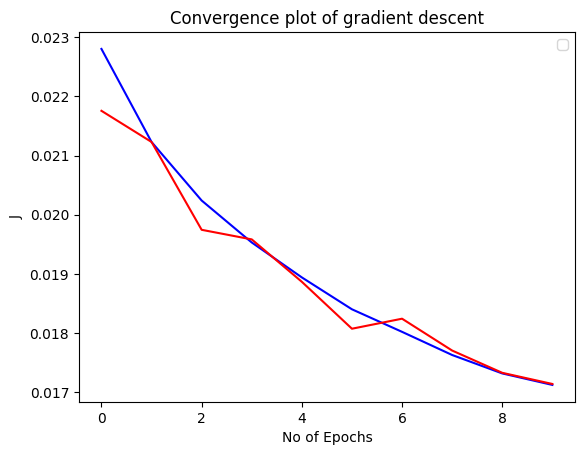

In [11]:
from matplotlib import pyplot as plt
plt.plot(train_history, 'b')
plt.plot(val_history, 'r')
plt.title('Convergence plot of gradient descent')
plt.xlabel('No of Epochs')
plt.ylabel('J')
plt.legend('train loss', 'val loss')
plt.show()

Actual cat	Predicted: cat
Actual ship	Predicted: ship
Actual ship	Predicted: ship
Actual airplane	Predicted: ship
Actual frog	Predicted: frog
Actual frog	Predicted: frog
Actual automobile	Predicted: automobile
Actual frog	Predicted: frog
Actual cat	Predicted: dog
Actual automobile	Predicted: automobile


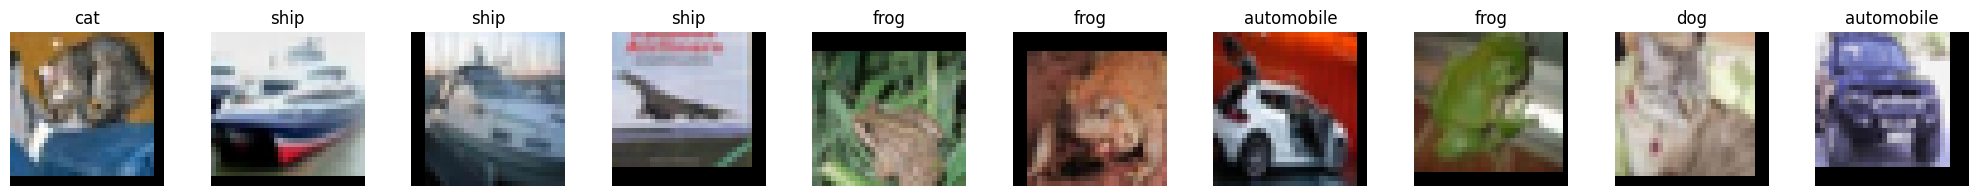

In [13]:
#Validate on test set

import torchvision

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)
    
outputs = model(images)
_, predicted = torch.max(outputs, dim=1)

plt.figure(figsize=(20,30))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.tight_layout()
    plt.imshow(transform_back(images[i]))
    plt.axis('off')
    plt.title(idx_to_class[predicted[i].item()])
    print(f"Actual {idx_to_class[labels[i].item()]}\tPredicted: {idx_to_class[predicted[i].item()]}")
plt.show()

In [15]:
correct = 0
total = 0
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total} %%')


Accuracy of the network on the 10000 test images: 61.16 %%


### Question 2: Transfer Learning with a Pretrained Model

Using a pretrained model (e.g., ResNet18 from torchvision), fine-tune it on a subset of CIFAR-10. Your solution must:

- Data Preprocessing & Input Adaptation (2 marks): Resize/normalize images as required by the pretrained network.

- Modify Final Layer with Weight Initialization (2 marks): Replace the final fully connected layer to match CIFAR-10’s classes and initialize its weights appropriately.

- Plotting results (1 mark): plot the loss and accuracy for train and test .

- Optimization & Learning Rate Scheduling (2 marks): Use a suitable optimizer and scheduler.

- Regularization & Error Metrics on Three-way Split (3 marks): Use dropout (if needed), split data, and compute accuracy.

In [10]:
print("CUDA available:", torch.cuda.is_available())
#print(next(model.parameters()).device)

CUDA available: False


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from torchvision.models import resnet18, ResNet18_Weights

In [4]:
# Data Preprocessing & Input Adaptation
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet18 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Loading dataset
full_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)

100%|██████████| 170M/170M [04:48<00:00, 592kB/s]  


In [24]:
# Splitting into training, validation, and testing
train_len = int(0.6 * len(full_dataset)) #60%
val_len = int(0.2 * len(full_dataset)) #20%
test_len = len(full_dataset) - train_len - val_len #20%
train_set, val_set, test_set = random_split(full_dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64)
test_loader = DataLoader(test_set, batch_size=64)

In [26]:
# Loading Pretrained Model & Modifying Final Layer
device = torch.device("cuda")
#model = models.resnet18(pretrained=True)
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Freezing all layers (optional)
for param in model.parameters():
    param.requires_grad = False

# Replacing the final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Initializing weights of new layer
nn.init.kaiming_normal_(model.fc.weight)
nn.init.zeros_(model.fc.bias)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [28]:
# Loss, Optimizer, and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [32]:
# Training Loop with logging
train_losses, val_losses = [], []
train_accs, val_accs = [], []

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    avg_loss = loss_sum / len(loader)
    return avg_loss, acc



epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step()

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

Epoch 1: Train Loss=1.0667, Val Loss=0.7228, Train Acc=0.6351, Val Acc=0.7555
Epoch 2: Train Loss=0.6782, Val Loss=0.6555, Train Acc=0.7684, Val Acc=0.7743
Epoch 3: Train Loss=0.6261, Val Loss=0.6153, Train Acc=0.7841, Val Acc=0.7868
Epoch 4: Train Loss=0.6031, Val Loss=0.6022, Train Acc=0.7937, Val Acc=0.7911
Epoch 5: Train Loss=0.5856, Val Loss=0.5908, Train Acc=0.7949, Val Acc=0.7955
Epoch 6: Train Loss=0.5595, Val Loss=0.5792, Train Acc=0.8070, Val Acc=0.7977
Epoch 7: Train Loss=0.5543, Val Loss=0.5745, Train Acc=0.8088, Val Acc=0.7967
Epoch 8: Train Loss=0.5492, Val Loss=0.5725, Train Acc=0.8100, Val Acc=0.8009
Epoch 9: Train Loss=0.5462, Val Loss=0.5788, Train Acc=0.8114, Val Acc=0.7957
Epoch 10: Train Loss=0.5419, Val Loss=0.5735, Train Acc=0.8133, Val Acc=0.7990


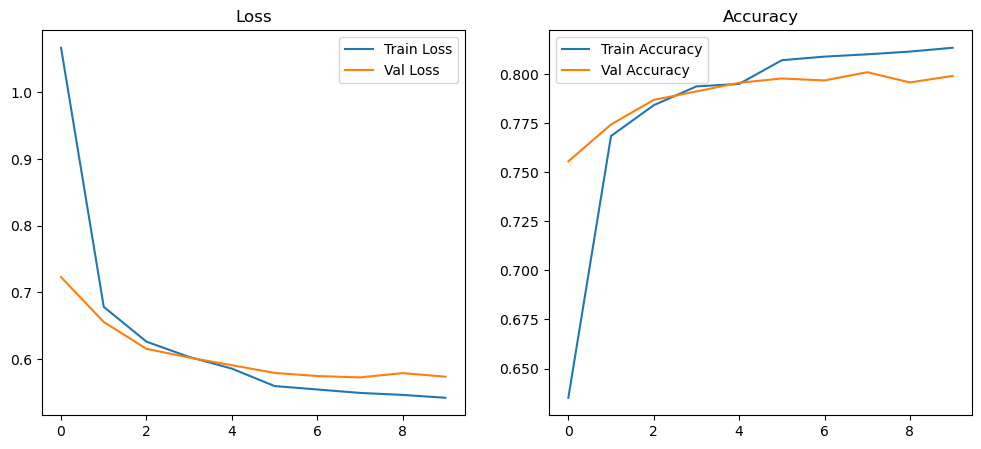

In [36]:
# Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.title("Accuracy")
plt.legend()

plt.show()

In [38]:
# Final test set evaluation
test_loss, test_acc = evaluate(test_loader)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8032, Test Loss: 0.5725


### Question 3: Implement a Custom FeatureSharpening Layer for Visually Similar Object Classification

In many real‐world tasks, subtle differences between classes (such as similar handwritten characters) make classification challenging. In this assignment, you are to design a custom layer—called FeatureSharpening—that applies a fixed Laplacian filter to highlight edge details and combines it with a learnable scaling parameter to “sharpen” the feature maps. Using the KMNIST dataset (which contains visually similar Japanese characters), build a CNN model that incorporates this layer to improve discrimination between classes. Your solution must have the following:

- Data Preprocessing & Three‑way Split (2 marks):
  - Load the KMNIST dataset.
  -Convert images to tensors and normalize them.
  -Split the dataset into training (70%), validation (15%), and testing (15%).

- Custom CNN Architecture & Weight Initialization (3 marks):
  - Build a CNN model with at least two convolutional layers.
  - Insert your custom FeatureSharpening layer after the first convolutional block.
  - Use proper weight initialization (e.g., Kaiming initialization) and activation functions.

- Implementation of the FeatureSharpening Layer (3 marks):

  - Create a custom PyTorch module called FeatureSharpening that:
    - Applies a fixed Laplacian filter (using a group convolution) to extract edge details.
    - Uses a learnable parameter to scale the filtered (edge) features.
    - Combines these with the original feature maps using a residual connection.
  - Provide a brief in-code comment explaining how this layer enhances subtle differences.

- Optimization, Learning Rate Scheduling & Regularization (1 mark):
  - Train the model using an optimizer (e.g., Adam) with a learning rate scheduler.
  - Optionally, include dropout for additional regularization.

- Error Metrics & Evaluation (1 mark):
  - Train your model for several epochs and report training/validation/test accuracies to show its performance.


In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

In [7]:
train_val_dataset = datasets.KMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.KMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 18.2M/18.2M [00:13<00:00, 1.33MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 186kB/s]
100%|██████████| 3.04M/3.04M [00:02<00:00, 1.27MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 1.09MB/s]


In [8]:
full_dataset = torch.utils.data.ConcatDataset([train_val_dataset, test_dataset])
total_size = len(full_dataset)  # Should be 70,000

# Calculate split sizes
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
#test_sze = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # To make sure sizes add up exactly

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

In [12]:
# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [14]:
class KMNISTNet(nn.Module):
    def __init__(self):
        super(KMNISTNet, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.sharpen = FeatureSharpening(channels=32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self._initialize_weights()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.sharpen(x)
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def _initialize_weights(self):
        # Kaiming He initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)


In [18]:
import torch.nn.functional as F

class FeatureSharpening(nn.Module):
    def __init__(self, channels):
        super(FeatureSharpening, self).__init__()
        self.scale = nn.Parameter(torch.tensor(0.5))  # Learnable parameter

        # Fixed Laplacian kernel (for edge detection)
        laplacian_kernel = torch.tensor([[0, -1, 0],
                                         [-1, 4, -1],
                                         [0, -1, 0]], dtype=torch.float32)
        laplacian_kernel = laplacian_kernel.expand(channels, 1, 3, 3)  # For group conv

        self.register_buffer('kernel', laplacian_kernel)
        self.groups = channels
        self.padding = 1  # To preserve spatial dimensions

    def forward(self, x):
        # Apply Laplacian filter via grouped convolution
        edge_map = F.conv2d(x, self.kernel, padding=self.padding, groups=self.groups)

        # Scale the edge features and add residual connection
        sharpened = x + self.scale * edge_map

        # This sharpening helps the model focus on subtle edges and details between similar characters
        return sharpened

In [15]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KMNISTNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


In [16]:
def train_model(num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        scheduler.step()

        # Validation
        val_acc = evaluate(val_loader)
        print(f"Epoch {epoch+1}: Train Acc = {train_acc:.2f}%, Val Acc = {val_acc:.2f}%")


In [19]:
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# Train the model
train_model(num_epochs=10)

# Final test accuracy
test_acc = evaluate(test_loader)
print(f"Test Accuracy: {test_acc:.2f}%")


Epoch 1: Train Acc = 85.06%, Val Acc = 94.73%
Epoch 2: Train Acc = 95.53%, Val Acc = 96.68%
Epoch 3: Train Acc = 97.12%, Val Acc = 97.29%
Epoch 4: Train Acc = 97.83%, Val Acc = 97.27%
Epoch 5: Train Acc = 98.31%, Val Acc = 97.06%
Epoch 6: Train Acc = 99.04%, Val Acc = 97.81%
Epoch 7: Train Acc = 99.32%, Val Acc = 97.77%
Epoch 8: Train Acc = 99.37%, Val Acc = 98.03%
Epoch 9: Train Acc = 99.39%, Val Acc = 97.80%
Epoch 10: Train Acc = 99.50%, Val Acc = 98.02%
Test Accuracy: 97.92%
